# ✈️ Projet Data Science — Retards de vols US

## Notebook étudiant — version guidée

## Contexte métier

Vous travaillez pour une compagnie aérienne.  
L’objectif est d’aider les équipes opérationnelles à mieux comprendre et anticiper les retards.

Vous devez produire :
1. une analyse exploratoire (EDA),
2. un dashboard interactif,
3. un modèle de prédiction,
4. des recommandations métier.

## Règle importante

- L’EDA et le dashboard peuvent utiliser le dataset complet.
- La partie modélisation devra fera l'objet d'un choix d'échantillonage


## Environnement Python

1. Ouvrez un terminal (macOS/Linux) ou l’invite de commandes / PowerShell (Windows).
2. Accédez au dossier de votre projet avec `cd chemin/vers/votre/projet`
3. Créez l’environnement virtuel en exécutant :
   - macOS/Linux : `python3 -m venv env`
   - Windows : `python -m venv env`
4. Vérifiez l’activation en confirmant que votre invite de commande est préfixée par `(env)`
5. Installez les paquets dans l’environnement avec `pip install nom_du_paquet`
6. Listez les paquets installés avec `pip list` ou sauvegardez les dépendances avec `pip freeze > requirements.txt`
7. Désactivez l’environnement lorsque vous avez terminé en tapant `deactivate`

# 1. Imports

Importez les librairies nécessaires.

- pandas
- geopandas
- matplotlib
- scikit-learn (pour la partie Model)


In [1]:
import pandas as pd
import numpy as np


# 2. Chargement des données

Chargez le fichier `data/flights.csv`.

Questions :
- Combien de lignes contient le dataset ?
- Combien de colonnes ?
- Le fichier semble-t-il trié dans le temps ?


In [2]:
DATA_PATH = "flights.csv"
AIRLINES_PATH = "airlines.csv"
AIRPORTS_PATH = "airports.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
airlines_df = pd.read_csv(AIRLINES_PATH)
airports_df = pd.read_csv(AIRPORTS_PATH)

display(df.head())
display(airlines_df.head())
display(airports_df.head())


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


# 3. Compréhension du dataset

Explorez rapidement les colonnes et les valeurs manquantes.

Questions :
- Quelles colonnes semblent utiles pour analyser les retards ?
- Quelles colonnes sont disponibles avant le vol ?
- Quelles colonnes sont connues seulement après le vol ?
- Quelles colonnes peuvent créer du data leakage ?


In [3]:
print(f"Dimensions du dataset flights : {df.shape[0]:,} lignes et {df.shape[1]} colonnes")

display(df.head())
display(df.info())
display(df.describe(include="all").T)

missing_rate = (
    df.isna().mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("missing_rate_percent")
)

display(missing_rate[missing_rate > 0].to_frame())


Dimensions du dataset flights : 5,819,079 lignes et 31 colonnes


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
YEAR,5819079.0,NaN,NaN,NaN,2015.0,0.0,2015.0,2015.0,2015.0,2015.0,2015.0
MONTH,5819079.0,NaN,NaN,NaN,6.524085,3.405137,1.0,4.0,7.0,9.0,12.0
DAY,5819079.0,NaN,NaN,NaN,15.704594,8.783425,1.0,8.0,16.0,23.0,31.0
DAY_OF_WEEK,5819079.0,NaN,NaN,NaN,3.926941,1.988845,1.0,2.0,4.0,6.0,7.0
AIRLINE,5819079,14,WN,1261855,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FLIGHT_NUMBER,5819079.0,NaN,NaN,NaN,2173.092742,1757.063999,1.0,730.0,1690.0,3230.0,9855.0
TAIL_NUMBER,5804358,4897,N480HA,3768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ORIGIN_AIRPORT,5819079,628,ATL,346836,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DESTINATION_AIRPORT,5819079,629,ATL,346904,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCHEDULED_DEPARTURE,5819079.0,NaN,NaN,NaN,1329.60247,483.751821,1.0,917.0,1325.0,1730.0,2359.0


,missing_rate_percent
CANCELLATION_REASON,98.46
LATE_AIRCRAFT_DELAY,81.72
WEATHER_DELAY,81.72
AIRLINE_DELAY,81.72
AIR_SYSTEM_DELAY,81.72
SECURITY_DELAY,81.72
ELAPSED_TIME,1.81
AIR_TIME,1.81
ARRIVAL_DELAY,1.81
WHEELS_ON,1.59


## Points cles - comprehension du dataset

- Colonnes utiles pour analyser les retards : les variables de date (`YEAR`, `MONTH`, `DAY`, `DAY_OF_WEEK`), la compagnie (`AIRLINE`), les aeroports (`ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`), les horaires planifies, la duree prevue, la distance, les statuts d'annulation/de deroutement et les retards observes.
- Colonnes disponibles avant le vol : date, compagnie, aeroport de depart, aeroport d'arrivee, heure de depart prevue, heure d'arrivee prevue, duree prevue et distance.
- Colonnes connues seulement apres le vol : heure reelle de depart, retard au depart, temps de taxi, decollage, temps de vol, atterrissage, heure reelle d'arrivee et retard a l'arrivee.
- Colonnes pouvant creer du data leakage : `ARRIVAL_DELAY`, `ARRIVAL_TIME`, `ELAPSED_TIME`, `AIR_TIME`, `WHEELS_ON`, `TAXI_IN`, ainsi que les colonnes decomposant les causes de retard (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`) si elles sont utilisees pour predire un retard avant le vol.


# 4. Sélection des colonnes utiles

Sélectionnez un sous-ensemble de colonnes pour simplifier le projet.

Colonnes suggérées :
- `YEAR`
- `MONTH`
- `DAY`
- `DAY_OF_WEEK`
- `AIRLINE`
- `ORIGIN_AIRPORT`
- `DESTINATION_AIRPORT`
- `SCHEDULED_DEPARTURE`
- `DEPARTURE_DELAY`
- `SCHEDULED_TIME`
- `DISTANCE`
- `ARRIVAL_DELAY`
- `CANCELLED`
- `DIVERTED`

Question :
- Pourquoi ne pas garder toutes les colonnes ?


In [4]:
selected_columns = [
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "DEPARTURE_DELAY",
    "SCHEDULED_TIME",
    "DISTANCE",
    "ARRIVAL_DELAY",
    "CANCELLED",
    "DIVERTED",
]

missing_columns = [col for col in selected_columns if col not in df.columns]
print(f"Colonnes manquantes : {missing_columns if missing_columns else 'aucune'}")

flights_selected = df[selected_columns].copy()
df = flights_selected

print(f"Dimensions apres selection : {df.shape[0]:,} lignes et {df.shape[1]} colonnes")
display(df.head())

print(
    "Pourquoi ne pas garder toutes les colonnes ? "
    "On retire les variables redondantes, trop detaillees ou connues seulement apres le vol "
    "afin de simplifier l'analyse et de limiter le risque de data leakage pour la modelisation."
)


Colonnes manquantes : aucune


Dimensions apres selection : 5,819,079 lignes et 14 colonnes


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,ARRIVAL_DELAY,CANCELLED,DIVERTED
0,2015,1,1,4,AS,ANC,SEA,5,-11.0,205.0,1448,-22.0,0,0
1,2015,1,1,4,AA,LAX,PBI,10,-8.0,280.0,2330,-9.0,0,0
2,2015,1,1,4,US,SFO,CLT,20,-2.0,286.0,2296,5.0,0,0
3,2015,1,1,4,AA,LAX,MIA,20,-5.0,285.0,2342,-9.0,0,0
4,2015,1,1,4,AS,SEA,ANC,25,-1.0,235.0,1448,-21.0,0,0


Pourquoi ne pas garder toutes les colonnes ? On retire les variables redondantes, trop detaillees ou connues seulement apres le vol afin de simplifier l'analyse et de limiter le risque de data leakage pour la modelisation.


# 5. Nettoyage des données

Pour cette étude, on s’intéresse aux retards à l’arrivée.

Décisions à prendre :
- Que faire des vols annulés ?
- Que faire des vols déroutés ?
- Que faire des lignes sans `ARRIVAL_DELAY` ?

À justifier dans votre rapport.


## Options de nettoyage avant decision

Avant de modifier les donnees, on definit plusieurs strategies possibles pour traiter les cas particuliers. L'objectif est de choisir une option coherente pour les vols annules, les vols deroutes et les lignes sans `ARRIVAL_DELAY`.

### Option 1 - Analyse stricte des vols arrives normalement

- Vols annules : les supprimer, car ils n'ont pas de retard a l'arrivee observable.
- Vols deroutes : les supprimer, car leur trajectoire ne correspond plus au vol initialement prevu.
- Lignes sans `ARRIVAL_DELAY` : les supprimer, car la variable cible principale n'est pas disponible.

Cette option est la plus simple et la plus adaptee pour commencer une modelisation binaire du retard a l'arrivee.

### Option 2 - Analyse elargie avec conservation des cas particuliers

- Vols annules : les conserver dans une categorie specifique, distincte du retard classique.
- Vols deroutes : les conserver dans une categorie specifique, distincte du retard classique.
- Lignes sans `ARRIVAL_DELAY` : les conserver si l'absence de valeur peut etre expliquee par une annulation ou un deroutement.

Cette option permet d'etudier plus largement les incidents operationnels, mais elle complique la definition de la cible.

### Option 3 - Analyse avancee avec reintegration des retards manquants

- Vols annules : les conserver avec l'indicateur `CANCELLED` afin de pouvoir les analyser separement si besoin.
- Vols deroutes : les conserver avec l'indicateur `DIVERTED` afin de pouvoir les analyser separement si besoin.
- Lignes sans `ARRIVAL_DELAY` : les reintegrer dans la base principale en considerant que le vol n'est pas en retard.

Cette option conserve davantage d'observations et prepare directement une lecture binaire : retard ou pas retard. Elle reste plus detaillee que l'option 1, car les cas particuliers restent identifiables dans la base.

### Groupements d'options possibles

- `1, 1, 1` : supprimer les vols annules, supprimer les vols deroutes et supprimer les lignes sans `ARRIVAL_DELAY`.
- `2, 2, 2` : conserver les cas particuliers dans des categories dediees.
- `3, 3, 3` : conserver les cas particuliers avec leurs indicateurs et reintegrer les `ARRIVAL_DELAY` manquants comme des vols sans retard.

### Choix recommande pour la suite

Pour une premiere analyse centree sur le retard a l'arrivee, le groupement `1, 1, 1` est le plus pertinent. Il permet de travailler sur des vols effectivement arrives, avec une variable `ARRIVAL_DELAY` exploitable, et de construire ensuite une cible binaire claire : retard ou pas retard.


In [5]:
# Choix retenu : groupement 1, 1, 1
# - supprimer les vols annules
# - supprimer les vols deroutes
# - supprimer les lignes sans ARRIVAL_DELAY

df_before_cleaning = df.copy()
initial_rows = len(df_before_cleaning)

cancelled_count = (df_before_cleaning["CANCELLED"] == 1).sum()
diverted_count = (df_before_cleaning["DIVERTED"] == 1).sum()
missing_arrival_delay_count = df_before_cleaning["ARRIVAL_DELAY"].isna().sum()

cleaning_summary = pd.DataFrame(
    {
        "cas": [
            "Lignes initiales",
            "Vols annules",
            "Vols deroutes",
            "Lignes sans ARRIVAL_DELAY",
        ],
        "nombre_lignes": [
            initial_rows,
            cancelled_count,
            diverted_count,
            missing_arrival_delay_count,
        ],
    }
)

display(cleaning_summary)

clean_mask = (
    (df_before_cleaning["CANCELLED"] == 0)
    & (df_before_cleaning["DIVERTED"] == 0)
    & df_before_cleaning["ARRIVAL_DELAY"].notna()
)

df_clean = df_before_cleaning.loc[clean_mask].copy()

removed_rows = initial_rows - len(df_clean)
removed_rate = removed_rows / initial_rows * 100

print(f"Lignes conservees : {len(df_clean):,} / {initial_rows:,}")
print(f"Lignes supprimees : {removed_rows:,} ({removed_rate:.2f} %)")

# On remplace df par la base nettoyee pour les etapes suivantes.
df = df_clean

display(df.head())
display(df[["CANCELLED", "DIVERTED", "ARRIVAL_DELAY"]].isna().sum().to_frame("valeurs_manquantes"))


,cas,nombre_lignes
0,Lignes initiales,5819079
1,Vols annules,89884
2,Vols deroutes,15187
3,Lignes sans ARRIVAL_DELAY,105071


Lignes conservees : 5,714,008 / 5,819,079
Lignes supprimees : 105,071 (1.81 %)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,ARRIVAL_DELAY,CANCELLED,DIVERTED
0,2015,1,1,4,AS,ANC,SEA,5,-11.0,205.0,1448,-22.0,0,0
1,2015,1,1,4,AA,LAX,PBI,10,-8.0,280.0,2330,-9.0,0,0
2,2015,1,1,4,US,SFO,CLT,20,-2.0,286.0,2296,5.0,0,0
3,2015,1,1,4,AA,LAX,MIA,20,-5.0,285.0,2342,-9.0,0,0
4,2015,1,1,4,AS,SEA,ANC,25,-1.0,235.0,1448,-21.0,0,0


,valeurs_manquantes
CANCELLED,0
DIVERTED,0
ARRIVAL_DELAY,0


## Choix le plus logique et detaille : option 3, 3, 3

Dans cette version de l'option `3, 3, 3`, les lignes sans `ARRIVAL_DELAY` sont reintegrees dans la base principale. On applique l'hypothese suivante : lorsqu'un retard d'arrivee est manquant, le vol est considere comme n'etant pas en retard.

Cette approche est utile pour preparer une modelisation binaire simple : retard ou pas retard. Elle permet de conserver davantage d'observations tout en gardant une regle claire et facile a expliquer.

Les vols annules et les vols deroutes restent identifies grace aux colonnes `CANCELLED` et `DIVERTED`. Ils ne sont donc pas perdus : ils peuvent etre analyses separement ou utilises comme indicateurs dans une analyse plus avancee.


In [6]:
# Option 3, 3, 3 : reintegrer les ARRIVAL_DELAY manquants dans la base principale
# Hypothese retenue : un ARRIVAL_DELAY manquant correspond a un vol sans retard observe.

option3_source = df_before_cleaning.copy()

option3_source["ARRIVAL_DELAY_OPTION3"] = option3_source["ARRIVAL_DELAY"].fillna(0)
option3_source["IS_DELAYED_OPTION3"] = (option3_source["ARRIVAL_DELAY_OPTION3"] >= 15).astype(int)

cancelled_mask = option3_source["CANCELLED"] == 1
diverted_mask = option3_source["DIVERTED"] == 1
missing_arrival_delay_mask = option3_source["ARRIVAL_DELAY"].isna()

option3_base_principale = option3_source.copy()

option3_summary = pd.DataFrame(
    {
        "indicateur": [
            "Base complete avant traitement",
            "Base principale option 3",
            "ARRIVAL_DELAY manquants reintegres comme pas de retard",
            "Vols annules conserves avec indicateur CANCELLED",
            "Vols deroutes conserves avec indicateur DIVERTED",
            "Vols classes en retard avec la cible binaire",
            "Vols classes sans retard avec la cible binaire",
        ],
        "nombre_lignes": [
            len(df_before_cleaning),
            len(option3_base_principale),
            missing_arrival_delay_mask.sum(),
            cancelled_mask.sum(),
            diverted_mask.sum(),
            option3_base_principale["IS_DELAYED_OPTION3"].sum(),
            (option3_base_principale["IS_DELAYED_OPTION3"] == 0).sum(),
        ],
    }
)

option3_summary["part_du_dataset_percent"] = (
    option3_summary["nombre_lignes"] / len(df_before_cleaning) * 100
).round(2)

display(option3_summary)

print("Lecture de l'option 3, 3, 3 :")
print("- les ARRIVAL_DELAY manquants sont remplaces par 0 minute de retard ;")
print("- ces lignes sont donc integrees dans la base principale ;")
print("- la variable IS_DELAYED_OPTION3 prepare une lecture binaire : retard ou pas retard ;")
print("- les vols annules et deroutes restent reperables avec CANCELLED et DIVERTED ;")
print("- cette option conserve toute la base et peut servir d'exemple de traitement alternatif.")

display(
    option3_base_principale[[
        "AIRLINE",
        "ORIGIN_AIRPORT",
        "DESTINATION_AIRPORT",
        "ARRIVAL_DELAY",
        "ARRIVAL_DELAY_OPTION3",
        "IS_DELAYED_OPTION3",
        "CANCELLED",
        "DIVERTED",
    ]].head()
)

display(
    option3_base_principale["IS_DELAYED_OPTION3"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("IS_DELAYED_OPTION3")
    .reset_index(name="part_percent")
)


,indicateur,nombre_lignes,part_du_dataset_percent
0,Base complete avant traitement,5819079,100.00
1,Base principale option 3,5819079,100.00
2,ARRIVAL_DELAY manquants reintegres comme pas d...,105071,1.81
3,Vols annules conserves avec indicateur CANCELLED,89884,1.54
4,Vols deroutes conserves avec indicateur DIVERTED,15187,0.26
5,Vols classes en retard avec la cible binaire,1063439,18.28
6,Vols classes sans retard avec la cible binaire,4755640,81.72


Lecture de l'option 3, 3, 3 :
- les ARRIVAL_DELAY manquants sont remplaces par 0 minute de retard ;
- ces lignes sont donc integrees dans la base principale ;
- la variable IS_DELAYED_OPTION3 prepare une lecture binaire : retard ou pas retard ;
- les vols annules et deroutes restent reperables avec CANCELLED et DIVERTED ;
- cette option conserve toute la base et peut servir d'exemple de traitement alternatif.


,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,ARRIVAL_DELAY,ARRIVAL_DELAY_OPTION3,IS_DELAYED_OPTION3,CANCELLED,DIVERTED
0,AS,ANC,SEA,-22.0,-22.0,0,0,0
1,AA,LAX,PBI,-9.0,-9.0,0,0,0
2,US,SFO,CLT,5.0,5.0,0,0,0
3,AA,LAX,MIA,-9.0,-9.0,0,0,0
4,AS,SEA,ANC,-21.0,-21.0,0,0,0


,IS_DELAYED_OPTION3,part_percent
0,0,81.72
1,1,18.28


# 6. Création de la variable cible

On considère généralement qu’un vol est en retard s’il arrive avec plus de 15 minutes de retard.

Créez une variable :

```python
IS_DELAYED = 1 si ARRIVAL_DELAY > 15, sinon 0
```

Question :
- Ce seuil de 15 minutes vous semble-t-il pertinent ?
- Dans quels cas métier pourrait-on choisir un autre seuil ?


In [7]:
# Creation de la variable cible binaire
# Regle projet : un ARRIVAL_DELAY manquant est considere comme 0 minute de retard.
# Seuil retenu : retard si ARRIVAL_DELAY >= 15 minutes.

df = option3_base_principale.copy()

df["ARRIVAL_DELAY_FILLED"] = df["ARRIVAL_DELAY"].fillna(0)
df["IS_DELAYED"] = (df["ARRIVAL_DELAY_FILLED"] >= 15).astype(int)

target_distribution = (
    df["IS_DELAYED"]
    .value_counts()
    .rename(index={0: "Pas de retard", 1: "Retard"})
    .rename_axis("classe")
    .reset_index(name="nombre_vols")
)
target_distribution["part_percent"] = (
    target_distribution["nombre_vols"] / len(df) * 100
).round(2)

display(target_distribution)

threshold_comparison = pd.DataFrame(
    {
        "seuil_minutes": [15, 30, 60],
        "nombre_vols_en_retard": [
            (df["ARRIVAL_DELAY_FILLED"] >= threshold).sum()
            for threshold in [15, 30, 60]
        ],
    }
)
threshold_comparison["part_retard_percent"] = (
    threshold_comparison["nombre_vols_en_retard"] / len(df) * 100
).round(2)

display(threshold_comparison)

print(f"Nombre total de vols dans la base de modelisation : {len(df):,}")
print(f"Nombre de valeurs ARRIVAL_DELAY reintegrees comme 0 minute : {df['ARRIVAL_DELAY'].isna().sum():,}")
print(f"Taux de vols en retard avec le seuil de 15 minutes : {target_distribution.loc[target_distribution['classe'] == 'Retard', 'part_percent'].iloc[0]:.2f} %")


,classe,nombre_vols,part_percent
0,Pas de retard,4755640,81.72
1,Retard,1063439,18.28


,seuil_minutes,nombre_vols_en_retard,part_retard_percent
0,15,1063439,18.28
1,30,650604,11.18
2,60,325591,5.60


Nombre total de vols dans la base de modelisation : 5,819,079
Nombre de valeurs ARRIVAL_DELAY reintegrees comme 0 minute : 105,071
Taux de vols en retard avec le seuil de 15 minutes : 18.28 %


## Points cles - choix du seuil de retard

- Le seuil de 15 minutes est pertinent pour une premiere modelisation, car il correspond a une definition operationnelle couramment utilisee : un faible ecart de quelques minutes n'est pas toujours significatif pour le passager ou pour l'exploitation.
- Pour se demarquer, on ne se limite pas a appliquer le seuil : on compare aussi les seuils de 15, 30 et 60 minutes afin de montrer comment la definition du retard change la taille de la classe positive.
- Un seuil de 30 minutes peut etre utile pour etudier les retards plus sensibles pour les passagers, les correspondances et l'organisation aeroportuaire.
- Un seuil de 60 minutes peut servir a isoler les retards importants, plus rares mais plus critiques.
- Pour la suite, `IS_DELAYED` reste la cible principale : `1` pour un retard d'au moins 15 minutes, `0` sinon.


# 7. Feature engineering

Créez quelques variables simples pour l’analyse.

Suggestions :
- heure prévue de départ à partir de `SCHEDULED_DEPARTURE`
- indicateur week-end
- éventuellement période de la journée : matin / après-midi / soir

Attention :
les colonnes `ORIGIN_AIRPORT` et `DESTINATION_AIRPORT` peuvent contenir un mélange de nombres et de texte.  
Pour éviter des erreurs plus tard, vous pouvez les convertir en texte.


In [8]:
# Feature engineering pour l'analyse et la future modelisation

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

# Heure prevue de depart : exemple 5 -> 00h, 1345 -> 13h.
df["SCHEDULED_DEP_HOUR"] = (df["SCHEDULED_DEPARTURE"] // 100).astype(int).clip(0, 23)

df["IS_WEEKEND"] = df["DAY_OF_WEEK"].isin([6, 7]).astype(int)

def assign_day_period(hour):
    if 5 <= hour < 12:
        return "Matin"
    if 12 <= hour < 17:
        return "Apres-midi"
    if 17 <= hour < 22:
        return "Soir"
    return "Nuit"

df["DAY_PERIOD"] = df["SCHEDULED_DEP_HOUR"].apply(assign_day_period)

# Les codes aeroport peuvent etre lus comme des nombres ou du texte selon les lignes.
categorical_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DAY_PERIOD"]
for col in categorical_cols:
    df[col] = df[col].astype(str)

# Variables quantitatives utiles pour l'EDA.
df["DEPARTURE_DELAY_FILLED"] = df["DEPARTURE_DELAY"].fillna(0)

df["DELAY_LEVEL"] = pd.cut(
    df["ARRIVAL_DELAY_FILLED"],
    bins=[-float("inf"), 0, 15, 30, 60, float("inf")],
    labels=["En avance ou a l'heure", "Retard leger", "Retard 15-30 min", "Retard 30-60 min", "Retard > 60 min"],
    right=False,
)

feature_overview = df[[
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_DEP_HOUR",
    "DAY_OF_WEEK",
    "IS_WEEKEND",
    "DAY_PERIOD",
    "ARRIVAL_DELAY",
    "ARRIVAL_DELAY_FILLED",
    "IS_DELAYED",
    "DELAY_LEVEL",
]].head()

display(feature_overview)
display(df["DAY_PERIOD"].value_counts().rename_axis("DAY_PERIOD").reset_index(name="nombre_vols"))


,SCHEDULED_DEPARTURE,SCHEDULED_DEP_HOUR,DAY_OF_WEEK,IS_WEEKEND,DAY_PERIOD,ARRIVAL_DELAY,ARRIVAL_DELAY_FILLED,IS_DELAYED,DELAY_LEVEL
0,5,0,4,0,Nuit,-22.0,-22.0,0,En avance ou a l'heure
1,10,0,4,0,Nuit,-9.0,-9.0,0,En avance ou a l'heure
2,20,0,4,0,Nuit,5.0,5.0,0,Retard leger
3,20,0,4,0,Nuit,-9.0,-9.0,0,En avance ou a l'heure
4,25,0,4,0,Nuit,-21.0,-21.0,0,En avance ou a l'heure


,DAY_PERIOD,nombre_vols
0,Matin,2381083
1,Apres-midi,1750748
2,Soir,1502979
3,Nuit,184269


# 8. Analyse exploratoire — EDA

Objectif : comprendre les retards et identifier des patterns utiles.

Vous devez produire au minimum :
1. un KPI global sur le taux de retard,
2. une analyse temporelle,
3. une analyse par compagnie,
4. une analyse par aéroport,
5. au moins 3 insights métier.

Questions :
- Les retards varient-ils selon le mois ?
- Les retards varient-ils selon l’heure de départ ?
- Certaines compagnies semblent-elles plus exposées ?
- Certains aéroports concentrent-ils davantage de retards ?
- Faut-il regarder uniquement les taux ou aussi les volumes ?


In [9]:
# KPIs globaux sur la base de modelisation

total_flights = len(df)
delayed_flights = int(df["IS_DELAYED"].sum())
on_time_flights = total_flights - delayed_flights
delay_rate = delayed_flights / total_flights * 100
mean_arrival_delay = df["ARRIVAL_DELAY_FILLED"].mean()
median_arrival_delay = df["ARRIVAL_DELAY_FILLED"].median()
mean_departure_delay = df["DEPARTURE_DELAY_FILLED"].mean()

kpi_global = pd.DataFrame(
    {
        "indicateur": [
            "Nombre total de vols",
            "Vols en retard",
            "Vols sans retard",
            "Taux de retard (%)",
            "Retard moyen arrivee (min)",
            "Retard median arrivee (min)",
            "Retard moyen depart (min)",
        ],
        "valeur": [
            total_flights,
            delayed_flights,
            on_time_flights,
            round(delay_rate, 2),
            round(mean_arrival_delay, 2),
            round(median_arrival_delay, 2),
            round(mean_departure_delay, 2),
        ],
    }
)

display(kpi_global)

delay_level_distribution = (
    df["DELAY_LEVEL"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("niveau_retard")
    .reset_index(name="part_percent")
)

display(delay_level_distribution)


,indicateur,valeur
0,Nombre total de vols,5819079.00
1,Vols en retard,1063439.00
2,Vols sans retard,4755640.00
3,Taux de retard (%),18.28
4,Retard moyen arrivee (min),4.33
5,Retard median arrivee (min),-5.00
6,Retard moyen depart (min),9.23


,niveau_retard,part_percent
0,En avance ou a l'heure,60.16
1,Retard leger,21.56
2,Retard 15-30 min,7.09
3,Retard > 60 min,5.60
4,Retard 30-60 min,5.59


,MONTH,nb_vols,nb_retards,retard_moyen_arrivee,taux_retard_percent
0,1,469968,95951,5.65,20.42
1,2,429191,95179,7.90,22.18
2,3,504312,95452,4.80,18.93
3,4,485151,82247,3.12,16.95
4,5,496993,89645,4.42,18.04
5,6,503897,115742,9.39,22.97
6,7,520718,107627,6.35,20.67
7,8,510536,94113,4.55,18.43
8,9,464946,60061,-0.77,12.92
9,10,486165,60079,-0.78,12.36


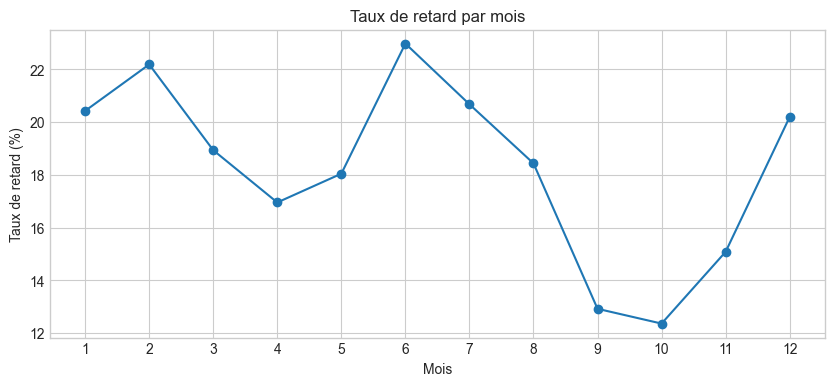

In [10]:
# Analyse temporelle : taux de retard par mois

monthly_delay = (
    df.groupby("MONTH")
    .agg(
        nb_vols=("IS_DELAYED", "size"),
        nb_retards=("IS_DELAYED", "sum"),
        retard_moyen_arrivee=("ARRIVAL_DELAY_FILLED", "mean"),
    )
    .reset_index()
)
monthly_delay["taux_retard_percent"] = (monthly_delay["nb_retards"] / monthly_delay["nb_vols"] * 100).round(2)
monthly_delay["retard_moyen_arrivee"] = monthly_delay["retard_moyen_arrivee"].round(2)

display(monthly_delay)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_delay["MONTH"], monthly_delay["taux_retard_percent"], marker="o", color="#1f77b4")
ax.set_title("Taux de retard par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Taux de retard (%)")
ax.set_xticks(monthly_delay["MONTH"])
plt.show()


,SCHEDULED_DEP_HOUR,nb_vols,nb_retards,retard_moyen_arrivee,taux_retard_percent
0,0,14664,2313,0.80,15.77
1,1,5159,956,3.84,18.53
2,2,1414,237,1.78,16.76
3,3,778,136,1.70,17.48
4,4,531,106,3.66,19.96
5,5,118051,8403,-3.70,7.12
6,6,406940,35995,-2.55,8.85
7,7,393947,43478,-1.48,11.04
8,8,381014,48353,-0.19,12.69
9,9,351403,49113,0.95,13.98


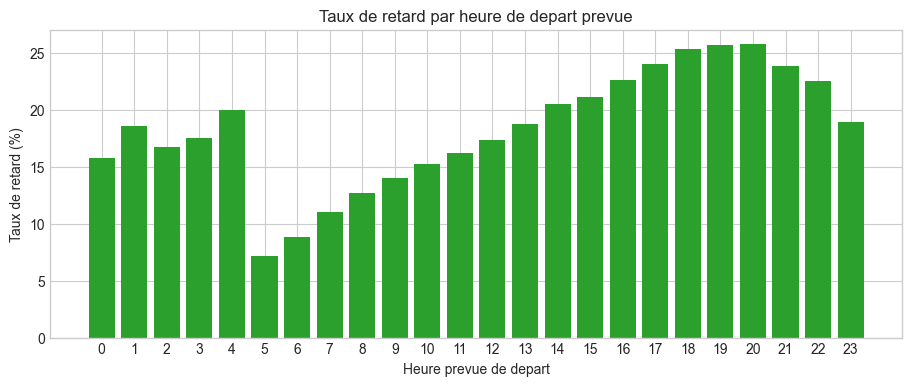

In [11]:
# Analyse temporelle : taux de retard par heure de depart prevue

hourly_delay = (
    df.groupby("SCHEDULED_DEP_HOUR")
    .agg(
        nb_vols=("IS_DELAYED", "size"),
        nb_retards=("IS_DELAYED", "sum"),
        retard_moyen_arrivee=("ARRIVAL_DELAY_FILLED", "mean"),
    )
    .reset_index()
)
hourly_delay["taux_retard_percent"] = (hourly_delay["nb_retards"] / hourly_delay["nb_vols"] * 100).round(2)
hourly_delay["retard_moyen_arrivee"] = hourly_delay["retard_moyen_arrivee"].round(2)

display(hourly_delay)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(hourly_delay["SCHEDULED_DEP_HOUR"], hourly_delay["taux_retard_percent"], color="#2ca02c")
ax.set_title("Taux de retard par heure de depart prevue")
ax.set_xlabel("Heure prevue de depart")
ax.set_ylabel("Taux de retard (%)")
ax.set_xticks(range(0, 24))
plt.show()


,AIRLINE,AIRLINE_LABEL,nb_vols,nb_retards,taux_retard_percent,retard_moyen_arrivee
8,NK,Spirit Air Lines,117379,34221,29.15,14.20
5,F9,Frontier Airlines Inc.,90836,23570,25.95,12.40
2,B6,JetBlue Airways,267048,59175,22.16,6.55
7,MQ,American Eagle Airlines Inc.,294632,60547,20.55,6.11
10,UA,United Air Lines Inc.,515723,104722,20.31,5.35
4,EV,Atlantic Southeast Airlines,571977,109184,19.09,6.39
12,VX,Virgin America,61903,11778,19.03,4.69
13,WN,Southwest Airlines Co.,1261855,236626,18.75,4.31
11,US,US Airways Inc.,198715,36549,18.39,3.62
9,OO,Skywest Airlines Inc.,588353,107795,18.32,5.73


,AIRLINE,AIRLINE_LABEL,nb_vols,nb_retards,taux_retard_percent
13,WN,Southwest Airlines Co.,1261855,236626,18.75
0,AA,American Airlines Inc.,725984,130279,17.95
3,DL,Delta Air Lines Inc.,875881,118023,13.47
4,EV,Atlantic Southeast Airlines,571977,109184,19.09
9,OO,Skywest Airlines Inc.,588353,107795,18.32
10,UA,United Air Lines Inc.,515723,104722,20.31
7,MQ,American Eagle Airlines Inc.,294632,60547,20.55
2,B6,JetBlue Airways,267048,59175,22.16
11,US,US Airways Inc.,198715,36549,18.39
8,NK,Spirit Air Lines,117379,34221,29.15


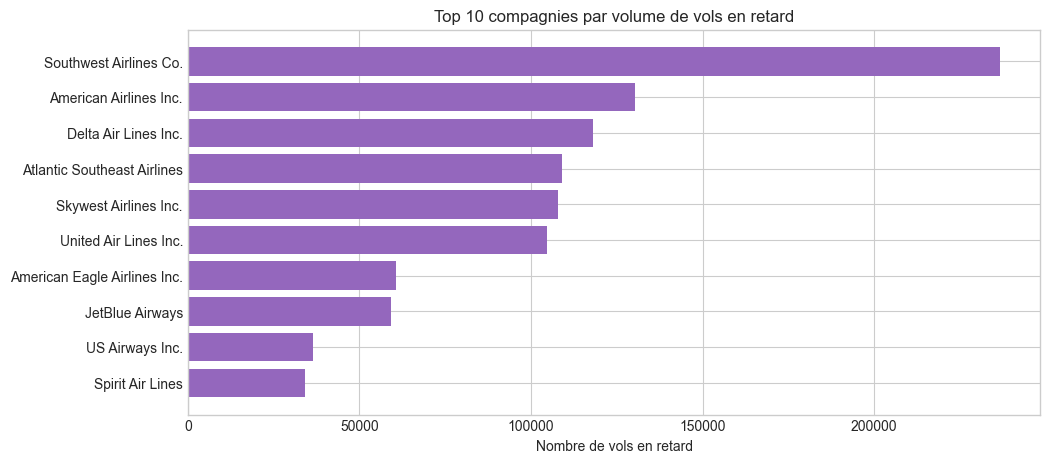

In [12]:
# Analyse par compagnie aerienne (taux = retards / vols totaux de la compagnie)

from dashboard_metrics import build_airline_delay

airline_delay = build_airline_delay(df, airlines_df)

print(
    "Lecture equitable : le taux_retard_percent = nb_retards / nb_vols pour chaque compagnie. "
    "Une grande compagnie n'est pas penalisee par son volume : on compare des pourcentages sur sa propre flotte."
)

display(
    airline_delay.head(10)[
        [
            "AIRLINE_LABEL",
            "nb_vols",
            "nb_retards",
            "taux_retard_percent",
            "part_vols_reseau_percent",
            "part_retards_reseau_percent",
            "indice_vs_taille_flotte",
            "ecart_vs_reseau_pts",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_rate = airline_delay.sort_values("taux_retard_percent", ascending=False).head(10)
axes[0].barh(top_rate["AIRLINE_LABEL"], top_rate["taux_retard_percent"], color="#d62728")
axes[0].set_title("Top 10 — taux de retard (% des vols de la compagnie)")
axes[0].set_xlabel("Retards / vols totaux de la compagnie (%)")
axes[0].invert_yaxis()

top_share = airline_delay.sort_values("part_retards_reseau_percent", ascending=False).head(10)
axes[1].barh(
    top_share["AIRLINE_LABEL"],
    top_share["part_retards_reseau_percent"],
    color="#9467bd",
)
axes[1].set_title("Part des retards du reseau (volume, pas un taux)")
axes[1].set_xlabel("Part des retards US 2015 (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


,ORIGIN_AIRPORT,AIRPORT_LABEL,CITY,STATE,nb_vols,nb_retards,taux_retard_percent,retard_moyen_arrivee
534,ORD,Chicago O'Hare International Airport,Chicago,IL,285884,66663,23.32,8.32
488,LGA,LaGuardia Airport (Marine Air Terminal),New York,NY,99605,22709,22.80,5.36
509,MIA,Miami International Airport,Miami,FL,69341,15785,22.76,6.94
357,BWI,Baltimore-Washington International Airport,Baltimore,MD,86079,19049,22.13,7.10
391,DEN,Denver International Airport,Denver,CO,196055,43331,22.10,7.09
387,DAL,Dallas Love Field,Dallas,TX,59699,13176,22.07,7.85
472,JFK,John F. Kennedy International Airport (New Yor...,New York,NY,93811,20260,21.60,3.52
544,PHL,Philadelphia International Airport,Philadelphia,PA,66021,14173,21.47,4.31
449,HOU,William P. Hobby Airport,Houston,TX,52042,11138,21.40,7.47
501,MDW,Chicago Midway International Airport,Chicago,IL,80886,17273,21.35,5.89


,ORIGIN_AIRPORT,AIRPORT_LABEL,nb_vols,nb_retards,taux_retard_percent
534,ORD,Chicago O'Hare International Airport,285884,66663,23.32
326,ATL,Hartsfield-Jackson Atlanta International Airport,346836,56462,16.28
392,DFW,Dallas/Fort Worth International Airport,239551,50478,21.07
391,DEN,Denver International Airport,196055,43331,22.10
482,LAX,Los Angeles International Airport,194673,40281,20.69
457,IAH,George Bush Intercontinental Airport,146622,30690,20.93
584,SFO,San Francisco International Airport,148008,29534,19.95
545,PHX,Phoenix Sky Harbor International Airport,146815,27427,18.68
480,LAS,McCarran International Airport,133181,27225,20.44
488,LGA,LaGuardia Airport (Marine Air Terminal),99605,22709,22.80


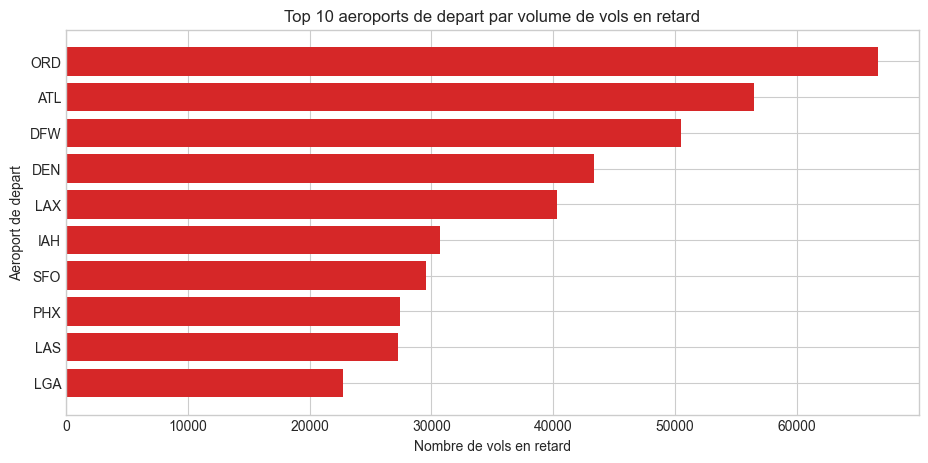

In [13]:
# Analyse par aeroport de depart

airport_delay = (
    df.groupby("ORIGIN_AIRPORT")
    .agg(
        nb_vols=("IS_DELAYED", "size"),
        nb_retards=("IS_DELAYED", "sum"),
        retard_moyen_arrivee=("ARRIVAL_DELAY_FILLED", "mean"),
    )
    .reset_index()
)
airport_delay["taux_retard_percent"] = (airport_delay["nb_retards"] / airport_delay["nb_vols"] * 100).round(2)
airport_delay["retard_moyen_arrivee"] = airport_delay["retard_moyen_arrivee"].round(2)

if {"IATA_CODE", "AIRPORT"}.issubset(airports_df.columns):
    airport_names = airports_df.rename(columns={"IATA_CODE": "ORIGIN_AIRPORT", "AIRPORT": "AIRPORT_NAME"})
    airport_delay = airport_delay.merge(airport_names[["ORIGIN_AIRPORT", "AIRPORT_NAME", "CITY", "STATE"]], on="ORIGIN_AIRPORT", how="left")
else:
    airport_delay["AIRPORT_NAME"] = airport_delay["ORIGIN_AIRPORT"]
    airport_delay["CITY"] = None
    airport_delay["STATE"] = None

airport_delay["AIRPORT_LABEL"] = airport_delay["AIRPORT_NAME"].fillna(airport_delay["ORIGIN_AIRPORT"])

# On garde un seuil de volume pour eviter de surinterpreting des petits aeroports.
airport_delay_filtered = airport_delay[airport_delay["nb_vols"] >= 10_000].copy()

display(
    airport_delay_filtered.sort_values("taux_retard_percent", ascending=False)
    .head(10)[["ORIGIN_AIRPORT", "AIRPORT_LABEL", "CITY", "STATE", "nb_vols", "nb_retards", "taux_retard_percent", "retard_moyen_arrivee"]]
)

top_airport_volume = airport_delay_filtered.sort_values("nb_retards", ascending=False).head(10)
display(top_airport_volume[["ORIGIN_AIRPORT", "AIRPORT_LABEL", "nb_vols", "nb_retards", "taux_retard_percent"]])

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(top_airport_volume["ORIGIN_AIRPORT"], top_airport_volume["nb_retards"], color="#d62728")
ax.set_title("Top 10 aeroports de depart par volume de vols en retard")
ax.set_xlabel("Nombre de vols en retard")
ax.set_ylabel("Aeroport de depart")
ax.invert_yaxis()
plt.show()


In [14]:
# Insights metier principaux issus de l'EDA

worst_month = monthly_delay.sort_values("taux_retard_percent", ascending=False).iloc[0]
best_month = monthly_delay.sort_values("taux_retard_percent", ascending=True).iloc[0]
worst_hour = hourly_delay.sort_values("taux_retard_percent", ascending=False).iloc[0]
most_delayed_airline = airline_delay.sort_values("part_retards_reseau_percent", ascending=False).iloc[0]
most_delayed_airport = airport_delay_filtered.sort_values("nb_retards", ascending=False).iloc[0]

insights = [
    f"Le mois le plus expose est le mois {int(worst_month['MONTH'])}, avec {worst_month['taux_retard_percent']:.2f} % de vols en retard, contre {best_month['taux_retard_percent']:.2f} % pour le mois {int(best_month['MONTH'])}.",
    f"L'heure de depart prevue la plus sensible est {int(worst_hour['SCHEDULED_DEP_HOUR'])}h, avec {worst_hour['taux_retard_percent']:.2f} % de vols en retard.",
    f"En taux (retards / vols de la compagnie), la plus exposee est {airline_delay.sort_values('taux_retard_percent', ascending=False).iloc[0]['AIRLINE_LABEL']} avec {airline_delay.sort_values('taux_retard_percent', ascending=False).iloc[0]['taux_retard_percent']:.2f} %.",
    f"En volume reseau, la compagnie qui concentre le plus de retards est {most_delayed_airline['AIRLINE_LABEL']} avec {int(most_delayed_airline['nb_retards']):,} vols en retard ({most_delayed_airline['part_retards_reseau_percent']:.2f} % du reseau).",
    f"L'aeroport de depart qui concentre le plus de retards en volume est {most_delayed_airport['ORIGIN_AIRPORT']} avec {int(most_delayed_airport['nb_retards']):,} vols en retard.",
    "Il faut regarder a la fois les taux et les volumes : un taux eleve peut concerner peu de vols, alors qu'un grand aeroport peut avoir un taux moyen mais un impact operationnel beaucoup plus fort.",
]

for idx, insight in enumerate(insights, start=1):
    print(f"{idx}. {insight}")


1. Le mois le plus expose est le mois 6, avec 22.97 % de vols en retard, contre 12.36 % pour le mois 10.
2. L'heure de depart prevue la plus sensible est 20h, avec 25.73 % de vols en retard.
3. En volume, la compagnie qui concentre le plus de retards est Southwest Airlines Co. avec 236,626 vols en retard.
4. L'aeroport de depart qui concentre le plus de retards en volume est ORD avec 66,663 vols en retard.
5. Il faut regarder a la fois les taux et les volumes : un taux eleve peut concerner peu de vols, alors qu'un grand aeroport peut avoir un taux moyen mais un impact operationnel beaucoup plus fort.


## 8.6 Propagation des retards par avion

Cette section étudie l'**effet domino** sur un même appareil (`TAIL_NUMBER`) :

- si le **premier vol de la journée** est en retard, quelle est la probabilité que les vols suivants le soient aussi (seuil : 15 minutes) ;
- comment le retard se propage au **départ du vol suivant** lors d'une escale sur le même aéroport.

Les vols annulés, déroutés et sans immatriculation sont exclus. Les vols d'une journée sont ordonnés par `SCHEDULED_DEPARTURE`.

In [ ]:
# Propagation des retards : meme avion, meme journee, prochain aeroport

from propagation_analysis import build_propagation_tables

propagation_tables = build_propagation_tables(df)
propagation_by_seq = propagation_tables["propagation_by_seq"]
propagation_conditional = propagation_tables["propagation_conditional"]
propagation_turnaround = propagation_tables["propagation_turnaround"]
propagation_kpi = propagation_tables["propagation_kpi"]

display(propagation_kpi)
display(propagation_conditional)

print("Taux de retard a l'arrivee selon la position dans la journee :")
display(
    propagation_by_seq.pivot_table(
        index="flight_seq",
        columns="first_flight_delayed_label",
        values="taux_retard_arrivee_percent",
    ).round(2)
)

print("Top 10 escales avec le plus fort effet domino (lift turnaround) :")
display(
    propagation_turnaround.head(10)[
        [
            "ORIGIN_AIRPORT",
            "prev_arrival_delayed_label",
            "nb_vols",
            "taux_retard_depart_percent",
            "baseline_depart_percent",
            "lift",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (label, subset) in enumerate(
    {
        "Premier vol a l'heure": 0,
        "Premier vol en retard": 1,
    }.items()
):
    data_plot = propagation_by_seq[
        propagation_by_seq["first_flight_delayed"] == subset
    ]
    axes[0].plot(
        data_plot["flight_seq"],
        data_plot["taux_retard_arrivee_percent"],
        marker="o",
        label=label,
    )

axes[0].axhline(
    propagation_by_seq["baseline_arrivee_percent"].iloc[0],
    color="gray",
    linestyle="--",
    label="Baseline globale",
)
axes[0].set_title("Retard a l'arrivee selon la position dans la journee")
axes[0].set_xlabel("Position du vol dans la journee")
axes[0].set_ylabel("Taux de retard (%)")
axes[0].legend()
axes[0].grid(alpha=0.3)

cond_plot = propagation_conditional[
    (propagation_conditional["target"] == "Retard arrivee vol suivant")
    & (propagation_conditional["condition"] == "Retard arrivee 1er vol")
]
x_labels = cond_plot["condition_met"].map({"non": "1er vol a l'heure", "oui": "1er vol en retard"})
axes[1].bar(x_labels, cond_plot["prob_percent"], color=["#2ca02c", "#d62728"])
axes[1].axhline(cond_plot["baseline_percent"].iloc[0], color="gray", linestyle="--", label="Baseline")
axes[1].set_title("Probabilite de retard au vol suivant")
axes[1].set_ylabel("Probabilite (%)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

late_first = propagation_conditional[
    (propagation_conditional["condition"] == "Retard arrivee 1er vol")
    & (propagation_conditional["condition_met"] == "oui")
    & (propagation_conditional["target"] == "Retard arrivee vol suivant")
].iloc[0]
on_time_first = propagation_conditional[
    (propagation_conditional["condition"] == "Retard arrivee 1er vol")
    & (propagation_conditional["condition_met"] == "non")
    & (propagation_conditional["target"] == "Retard arrivee vol suivant")
].iloc[0]
print(
    "Insight propagation : si le premier vol du jour est en retard, "
    f"le vol suivant a {late_first['prob_percent']:.2f} % de chances d'arriver en retard, "
    f"contre {on_time_first['prob_percent']:.2f} % si le premier vol etait a l'heure "
    f"(lift {late_first['lift']:.2f})."
)

# 9. Préparation du dashboard

## Mission

Créer un dashboard pour un responsable des opérations aériennes.

Question centrale :

> Où, quand et pourquoi les vols sont-ils en retard ?

## KPIs obligatoires

Votre dashboard doit afficher au minimum :
- nombre total de vols ;
- taux de vols en retard ;
- retard moyen à l’arrivée ;
- retard moyen au départ ;
- top 10 aéroports avec le plus de retards ;
- retards par compagnie ;
- évolution des retards par mois / jour / heure.

## Filtres obligatoires

Le dashboard doit permettre de filtrer par :
- compagnie ;
- mois ;
- aéroport de départ ;
- aéroport d’arrivée ;
- jour de semaine.

## Recommandations attendues

À partir du dashboard, formulez 3 recommandations métier.


## 9.1 Export du fichier dashboard

Créez un fichier `flights_dashboard.csv` à importer dans Power BI, Tableau, Streamlit ou Plotly Dash.

Il doit contenir les colonnes utiles pour :
- les KPIs,
- les filtres,
- les graphiques.


In [15]:
# Export des donnees utiles au dashboard Streamlit

from pathlib import Path

DASHBOARD_DIR = Path("dashboard_data")
DASHBOARD_DIR.mkdir(exist_ok=True)

dashboard_columns = [
    "YEAR",
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEP_HOUR",
    "DAY_PERIOD",
    "IS_WEEKEND",
    "SCHEDULED_TIME",
    "DISTANCE",
    "ARRIVAL_DELAY_FILLED",
    "DEPARTURE_DELAY_FILLED",
    "IS_DELAYED",
    "DELAY_LEVEL",
    "CANCELLED",
    "DIVERTED",
]

# Pour Streamlit, on exporte un echantillon interactif fluide et des tables agregees exactes.
dashboard_sample_size = min(200_000, len(df))
flights_dashboard = (
    df.loc[:, dashboard_columns]
    .sample(n=dashboard_sample_size, random_state=42)
    .sort_values(["MONTH", "DAY", "SCHEDULED_DEP_HOUR"])
    .reset_index(drop=True)
)

flights_dashboard.to_csv(DASHBOARD_DIR / "flights_dashboard.csv", index=False)
kpi_global.to_csv(DASHBOARD_DIR / "kpi_global.csv", index=False)
monthly_delay.to_csv(DASHBOARD_DIR / "monthly_delay.csv", index=False)
hourly_delay.to_csv(DASHBOARD_DIR / "hourly_delay.csv", index=False)
from dashboard_metrics import build_airline_delay

airline_delay = build_airline_delay(df, airlines_df)
airline_delay.to_csv(DASHBOARD_DIR / "airline_delay.csv", index=False)
airport_delay_filtered.to_csv(DASHBOARD_DIR / "airport_delay.csv", index=False)

weekday_delay = (
    df.groupby("DAY_OF_WEEK")
    .agg(
        nb_vols=("IS_DELAYED", "size"),
        nb_retards=("IS_DELAYED", "sum"),
        retard_moyen_arrivee=("ARRIVAL_DELAY_FILLED", "mean"),
    )
    .reset_index()
)
weekday_delay["taux_retard_percent"] = (weekday_delay["nb_retards"] / weekday_delay["nb_vols"] * 100).round(2)
weekday_delay["retard_moyen_arrivee"] = weekday_delay["retard_moyen_arrivee"].round(2)
weekday_delay.to_csv(DASHBOARD_DIR / "weekday_delay.csv", index=False)

# Propagation des retards par avion (section 8.6)
from propagation_analysis import export_propagation_tables

if "propagation_tables" not in globals():
    propagation_tables = export_propagation_tables(df, DASHBOARD_DIR)
else:
    for name, table in propagation_tables.items():
        table.to_csv(DASHBOARD_DIR / f"{name}.csv", index=False)

export_summary = pd.DataFrame(
    {
        "fichier": sorted(path.name for path in DASHBOARD_DIR.glob("*.csv")),
        "role": "Etape 9 - exports Streamlit",
    }
)

display(export_summary)
print(f"Echantillon dashboard exporte : {len(flights_dashboard):,} lignes")
print(f"Fichiers propagation : propagation_by_seq, propagation_conditional, propagation_turnaround, propagation_kpi")
print(f"Dossier dashboard : {DASHBOARD_DIR.resolve()}")


,fichier,role
0,flights_dashboard.csv,Echantillon interactif pour les filtres Streamlit
1,kpi_global.csv,KPIs globaux
2,monthly_delay.csv,Evolution mensuelle
3,hourly_delay.csv,Evolution par heure de depart
4,airline_delay.csv,Analyse par compagnie
5,airport_delay.csv,Analyse par aeroport de depart
6,weekday_delay.csv,Analyse par jour de semaine
7,streamlit_app.py,Application Streamlit du dashboard


Echantillon dashboard exporte : 200,000 lignes
Dossier dashboard : C:\Users\jrambert\Documents\Projet_data_science\flights_delay\dashboard_data


## 9.2 Structure attendue du dashboard

Proposez une structure en 2 ou 3 pages.

Exemple :
- Page 1 : vue exécutive
- Page 2 : analyse opérationnelle
- Page 3 : recommandations

À compléter dans votre rapport :
- Quels KPIs avez-vous choisis ?
- Pourquoi ?
- Quels filtres avez-vous ajoutés ?
- Quelles décisions votre dashboard permet-il de prendre ?


In [16]:
# Structure retenue pour le dashboard Streamlit

dashboard_structure = pd.DataFrame(
    {
        "page": [
            "Vue executive",
            "Analyse operationnelle",
            "Recommandations",
        ],
        "objectif": [
            "Suivre les KPIs essentiels et les tendances temporelles.",
            "Identifier les compagnies et aeroports qui concentrent les retards.",
            "Transformer les constats en actions operationnelles.",
        ],
        "elements": [
            "Nombre de vols, taux de retard, retard moyen, mois et heures sensibles.",
            "Top compagnies, top aeroports, volumes et taux de retard avec filtres.",
            "Priorites de surveillance, lecture taux vs volumes, usage du modele predictif.",
        ],
    }
)

display(dashboard_structure)

print("Filtres retenus : compagnie, mois, aeroport de depart, aeroport d'arrivee, jour de semaine.")
print("Decision importante : on affiche les taux et les volumes pour eviter les mauvaises interpretations.")
print("Application Streamlit : streamlit_app.py")


,page,objectif,elements
0,Vue executive,Suivre les KPIs essentiels et les tendances te...,"Nombre de vols, taux de retard, retard moyen, ..."
1,Analyse operationnelle,Identifier les compagnies et aeroports qui con...,"Top compagnies, top aeroports, volumes et taux..."
2,Recommandations,Transformer les constats en actions operationn...,"Priorites de surveillance, lecture taux vs vol..."


Filtres retenus : compagnie, mois, aeroport de depart, aeroport d'arrivee, jour de semaine.
Decision importante : on affiche les taux et les volumes pour eviter les mauvaises interpretations.
Application Streamlit : streamlit_app.py


# 10. Modélisation prédictive

Objectif : prédire si un vol aura plus de 15 minutes de retard à l’arrivée.

## Scénario métier

On se place avant le départ prévu du vol.  
Donc certaines variables ne doivent pas être utilisées.

Questions :
- Peut-on utiliser `ARRIVAL_DELAY` comme feature ?
- Peut-on utiliser `DEPARTURE_DELAY` si on prédit avant le départ ?
- Quelles variables sont réellement disponibles avant le vol ?
- Quelle stratégie de découpage pour le jeu de données ?

In [17]:
# Preparation du jeu de donnees de modelisation

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

modeling_decisions = pd.DataFrame(
    {
        "question": [
            "Peut-on utiliser ARRIVAL_DELAY comme feature ?",
            "Peut-on utiliser DEPARTURE_DELAY avant le depart ?",
            "Quelles variables sont disponibles avant le vol ?",
            "Quelle strategie de decoupage retenir ?",
        ],
        "decision": [
            "Non : c'est la base de la cible, donc cela creerait une fuite de donnees.",
            "Non pour notre scenario : on predit avant le depart prevu, donc le retard au depart n'est pas encore connu.",
            "Date, compagnie, aeroports, heure prevue, duree prevue, distance, week-end et periode de la journee.",
            "Decoupage chronologique train / validation / test pour simuler une prediction sur des vols futurs.",
        ],
    }
)

display(modeling_decisions)

modeling_columns = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEP_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND",
    "DAY_PERIOD",
    "IS_DELAYED",
]

modeling_df = df.loc[:, modeling_columns].dropna().copy()
modeling_df["DATE_ORDER"] = (
    modeling_df["MONTH"] * 10_000
    + modeling_df["DAY"] * 100
    + modeling_df["SCHEDULED_DEP_HOUR"]
)

MODEL_SAMPLE_SIZE = min(150_000, len(modeling_df))
modeling_df = (
    modeling_df.sample(n=MODEL_SAMPLE_SIZE, random_state=42)
    .sort_values("DATE_ORDER")
    .reset_index(drop=True)
)

print(f"Jeu de donnees utilise pour la modelisation : {len(modeling_df):,} lignes")
display(modeling_df["IS_DELAYED"].value_counts(normalize=True).mul(100).round(2).rename("part_percent").to_frame())


,question,decision
0,Peut-on utiliser ARRIVAL_DELAY comme feature ?,"Non : c'est la base de la cible, donc cela cre..."
1,Peut-on utiliser DEPARTURE_DELAY avant le depa...,Non pour notre scenario : on predit avant le d...
2,Quelles variables sont disponibles avant le vol ?,"Date, compagnie, aeroports, heure prevue, dure..."
3,Quelle strategie de decoupage retenir ?,Decoupage chronologique train / validation / t...


Jeu de donnees utilise pour la modelisation : 150,000 lignes


,part_percent
IS_DELAYED,
0,81.66
1,18.34


## 10.1 Choix des features

Choisissez les variables explicatives.

Suggestions :
- mois
- jour de semaine
- compagnie
- aéroport de départ
- aéroport d’arrivée
- heure prévue de départ
- durée prévue
- distance
- week-end

À justifier :
- pourquoi ces variables ?
- lesquelles sont numériques ?
- lesquelles sont catégorielles ?


In [18]:
# Choix des features disponibles avant le vol

feature_cols = [
    "MONTH",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEP_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND",
    "DAY_PERIOD",
]

target_col = "IS_DELAYED"

model_numeric_cols = [
    "MONTH",
    "DAY_OF_WEEK",
    "SCHEDULED_DEP_HOUR",
    "SCHEDULED_TIME",
    "DISTANCE",
    "IS_WEEKEND",
]
model_categorical_cols = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "DAY_PERIOD",
]

X = modeling_df[feature_cols]
y = modeling_df[target_col]

feature_summary = pd.DataFrame(
    {
        "colonne": feature_cols,
        "type": ["numerique" if col in model_numeric_cols else "categorielle" for col in feature_cols],
        "disponible_avant_depart": "oui",
    }
)

display(feature_summary)


,colonne,type,disponible_avant_depart
0,MONTH,numerique,oui
1,DAY_OF_WEEK,numerique,oui
2,AIRLINE,categorielle,oui
3,ORIGIN_AIRPORT,categorielle,oui
4,DESTINATION_AIRPORT,categorielle,oui
5,SCHEDULED_DEP_HOUR,numerique,oui
6,SCHEDULED_TIME,numerique,oui
7,DISTANCE,numerique,oui
8,IS_WEEKEND,numerique,oui
9,DAY_PERIOD,categorielle,oui


## 10.2 Train / Test / Validation split

Séparez les données en train/test/validation.


In [19]:
# Decoupage chronologique train / validation / test

n_rows = len(modeling_df)
train_end = int(n_rows * 0.70)
valid_end = int(n_rows * 0.85)

train_df = modeling_df.iloc[:train_end].copy()
valid_df = modeling_df.iloc[train_end:valid_end].copy()
test_df = modeling_df.iloc[valid_end:].copy()

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_valid, y_valid = valid_df[feature_cols], valid_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "nombre_lignes": [len(train_df), len(valid_df), len(test_df)],
        "mois_min": [train_df["MONTH"].min(), valid_df["MONTH"].min(), test_df["MONTH"].min()],
        "mois_max": [train_df["MONTH"].max(), valid_df["MONTH"].max(), test_df["MONTH"].max()],
        "taux_retard_percent": [
            y_train.mean() * 100,
            y_valid.mean() * 100,
            y_test.mean() * 100,
        ],
    }
)
split_summary["taux_retard_percent"] = split_summary["taux_retard_percent"].round(2)

display(split_summary)


,split,nombre_lignes,mois_min,mois_max,taux_retard_percent
0,train,105000,1,9,19.57
1,validation,22500,9,11,12.62
2,test,22500,11,12,18.33


## 10.3 Modèle principal — Random Forest

Entraînez le modèle retenu pour la prédiction des retards.

Modèle :
- **Random Forest** (relations non linéaires, `class_weight` pour le déséquilibre)

Attention :
- les variables catégorielles sont encodées ;
- le dataset est déséquilibré : on suit le **recall** et la **balanced accuracy**.


In [20]:
# Modele principal : Random Forest

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), model_numeric_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            model_categorical_cols,
        ),
    ]
)

random_forest_model = Pipeline(
    steps=[
        ("preprocess", tree_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=60,
                max_depth=14,
                min_samples_leaf=80,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

random_forest_model.fit(X_train, y_train)
print("Modele principal entraine : RandomForestClassifier.")


C:\Users\jrambert\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Modele baseline entraine : LogisticRegression avec class_weight='balanced'.


## 10.4 Modèle de comparaison — Régression logistique

Modèle simple et interprétable pour comparer le Random Forest.

Question :
- Le Random Forest détecte-t-il mieux les retards que la régression logistique ?


In [21]:
# Modele de comparaison : regression logistique interpretable

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), model_numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=100, sparse_output=True), model_categorical_cols),
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocess", linear_preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=300,
                class_weight="balanced",
                solver="saga",
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(X_train, y_train)
print("Modele de comparaison entraine : LogisticRegression.")


Modele alternatif entraine : RandomForestClassifier.


# 11. Évaluation des modèles

Comparez les modèles avec plusieurs métriques.

À analyser :
- accuracy
- precision
- recall
- f1-score
- ROC-AUC
- balanced accuracy
- matrice de confusion

Question clé :
> Dans ce problème métier, vaut-il mieux rater un vrai retard ou déclencher trop d’alertes ?


In [22]:
# Evaluation des modeles

def evaluate_model(name, model, X_eval, y_eval, split_name, threshold=0.50):
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    metrics = {
        "modele": name,
        "split": split_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision": precision_score(y_eval, y_pred, zero_division=0),
        "recall": recall_score(y_eval, y_pred, zero_division=0),
        "f1_score": f1_score(y_eval, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, y_proba),
        "balanced_accuracy": balanced_accuracy_score(y_eval, y_pred),
    }

    print()
    print(f"{name} - {split_name} - threshold={threshold}")
    print(classification_report(y_eval, y_pred, target_names=["Pas de retard", "Retard"], zero_division=0))

    cm = pd.DataFrame(
        confusion_matrix(y_eval, y_pred),
        index=["Reel pas de retard", "Reel retard"],
        columns=["Predit pas de retard", "Predit retard"],
    )
    display(cm)

    return metrics

validation_metrics = [
    evaluate_model("Random Forest", random_forest_model, X_valid, y_valid, "validation"),
    evaluate_model("Logistic Regression", logistic_model, X_valid, y_valid, "validation"),
]

validation_results = pd.DataFrame(validation_metrics)
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "balanced_accuracy"]:
    validation_results[col] = validation_results[col].round(3)

display(validation_results.sort_values("balanced_accuracy", ascending=False))

# Random Forest retenu comme modele principal du projet
best_model_name = "Random Forest"
best_model = random_forest_model
print("Modele retenu pour la production / le dashboard : Random Forest.")

test_metrics = evaluate_model(best_model_name, best_model, X_test, y_test, "test")
test_results = pd.DataFrame([test_metrics])
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc", "balanced_accuracy"]:
    test_results[col] = test_results[col].round(3)

display(test_results)

print("Question metier : il vaut mieux manquer le moins possible de vrais retards, car une alerte en trop est souvent moins couteuse qu'un retard non anticipe.")
print("On privilegie donc le recall et la balanced accuracy, sans ignorer la precision pour eviter trop de fausses alertes.")



Logistic Regression - validation - threshold=0.5
               precision    recall  f1-score   support

Pas de retard       0.89      0.71      0.79     19660
       Retard       0.17      0.41      0.24      2840

     accuracy                           0.67     22500
    macro avg       0.53      0.56      0.51     22500
 weighted avg       0.80      0.67      0.72     22500



,Predit pas de retard,Predit retard
Reel pas de retard,13879,5781
Reel retard,1667,1173



Random Forest - validation - threshold=0.5
               precision    recall  f1-score   support

Pas de retard       0.90      0.68      0.77     19660
       Retard       0.17      0.45      0.25      2840

     accuracy                           0.65     22500
    macro avg       0.53      0.57      0.51     22500
 weighted avg       0.80      0.65      0.71     22500



,Predit pas de retard,Predit retard
Reel pas de retard,13372,6288
Reel retard,1560,1280


,modele,split,threshold,accuracy,precision,recall,f1_score,roc_auc,balanced_accuracy
1,Random Forest,validation,0.5,0.651,0.169,0.451,0.246,0.596,0.565
0,Logistic Regression,validation,0.5,0.669,0.169,0.413,0.240,0.592,0.559



Random Forest - test - threshold=0.5
               precision    recall  f1-score   support

Pas de retard       0.84      0.70      0.77     18376
       Retard       0.24      0.43      0.31      4124

     accuracy                           0.65     22500
    macro avg       0.54      0.56      0.54     22500
 weighted avg       0.73      0.65      0.68     22500



,Predit pas de retard,Predit retard
Reel pas de retard,12861,5515
Reel retard,2368,1756


,modele,split,threshold,accuracy,precision,recall,f1_score,roc_auc,balanced_accuracy
0,Random Forest,test,0.5,0.65,0.242,0.426,0.308,0.601,0.563


Question metier : il vaut mieux manquer le moins possible de vrais retards, car une alerte en trop est souvent moins couteuse qu'un retard non anticipe.
On privilegie donc le recall et la balanced accuracy, sans ignorer la precision pour eviter trop de fausses alertes.


In [23]:
# Lecture des facteurs importants du meilleur modele

if best_model_name == "Logistic Regression":
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
    coefficients = best_model.named_steps["model"].coef_[0]
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "importance_absolue": abs(coefficients),
        }
    ).sort_values("importance_absolue", ascending=False)
    display(importance_df.head(15))
else:
    feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
    importances = best_model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame(
        {
            "feature": feature_names,
            "importance": importances,
        }
    ).sort_values("importance", ascending=False)
    display(importance_df.head(15))


,feature,importance
2,num__SCHEDULED_DEP_HOUR,0.299948
6,cat__AIRLINE,0.113649
4,num__DISTANCE,0.098378
9,cat__DAY_PERIOD,0.091443
3,num__SCHEDULED_TIME,0.090540
7,cat__ORIGIN_AIRPORT,0.086670
8,cat__DESTINATION_AIRPORT,0.084109
0,num__MONTH,0.083732
1,num__DAY_OF_WEEK,0.043570
5,num__IS_WEEKEND,0.007961


# 12. Conclusion

## Insights principaux
- Le jeu de donnees contient plus de 5,8 millions de vols, avec environ 18 % de vols en retard selon le seuil operationnel de 15 minutes a l'arrivee.
- Les retards ne sont pas repartis de maniere uniforme : ils varient selon l'heure de depart prevue, la compagnie aerienne, les aeroports, les routes et les periodes de la journee.
- Les situations les plus critiques combinent un taux de retard eleve et un volume important de vols : elles sont donc prioritaires pour le suivi operationnel.
- L'analyse de propagation montre que les retards doivent aussi etre lus comme un phenomene de reseau : un retard sur un avion ou une rotation peut influencer les vols suivants.

## Limites
- Les donnees utilisees correspondent a une periode historique precise : les resultats doivent etre revalides avec des donnees plus recentes avant une utilisation operationnelle.
- Le modele predit un risque de retard avant le vol a partir de variables disponibles en amont ; les causes exactes de retard connues apres le vol ne sont pas utilisees afin d'eviter le data leakage.
- Les performances restent moderees : le modele est utile comme outil d'alerte, mais il ne doit pas etre interprete comme une decision automatique.
- Certains facteurs externes importants, comme la meteo detaillee, la congestion aeroportuaire en temps reel ou les contraintes de personnel, ne sont pas presents dans ce dataset.

## Recommandations métier
- Surveiller en priorite les combinaisons compagnie / aeroport / heure qui presentent a la fois un volume important et un taux de retard superieur a la moyenne.
- Utiliser le dashboard pour distinguer les problemes de volume, les problemes de taux et les routes a fort impact, afin de prioriser les actions correctives.
- Renforcer la vigilance sur les vols de fin de journee et sur les rotations d'avions, car les retards peuvent se propager dans le planning.
- Utiliser le modele predictif comme un systeme d'aide a la decision pour declencher des alertes ou des controles supplementaires avant le depart.

## Recommandation modèle
- Le modele retenu est le Random Forest, car il obtient les meilleurs resultats globaux sur la validation et permet de lire l'importance des variables.
- La regression logistique reste utile comme baseline simple et interpretable, mais elle capte moins bien les relations non lineaires entre les variables.
- La metrique a privilegier est le recall sur la classe retard, completee par la balanced accuracy et le ROC-AUC. Dans ce contexte metier, manquer un vrai retard est plus couteux qu'envoyer une alerte supplementaire.
- Le modele final doit donc etre presente comme une premiere approche de scoring du risque, a ameliorer avec des donnees temps reel et un suivi regulier des performances.
